# 🌟 Pokémon TCG AI Battle Challenge - Exploratory Data Analysis 🌟

Welcome to the Exploratory Data Analysis (EDA) notebook for the **Pokémon TCG AI Battle Challenge**. 

This notebook is designed to work seamlessly in the Kaggle environment. It explores the English dataset (`EN_Card_Data.csv`) to provide insights into card distributions, Pokémon stats, attack damage, and more. This will help you understand the card pool available to the AI simulator.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and Clean Data
We first locate the dataset. Kaggle stores datasets in `/kaggle/input/`, so we'll dynamically search for our file. If running locally, it defaults to the current directory.

In [2]:
file_path = '/kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/EN_Card_Data.csv'

print(f"Loading data from: {file_path}")

try:
    df = pd.read_csv(file_path)
    
    # Clean column names (strip whitespaces)
    df.columns = df.columns.str.strip()
    
    # Clean string columns (strip trailing spaces from values)
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.strip()
        # Replace 'n/a', 'nan', 'None' with actual NaNs
        df[col] = df[col].replace({'n/a': np.nan, 'nan': np.nan, 'None': np.nan})
        
    print(f"Dataset loaded successfully. Shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")

Loading data from: /kaggle/input/competitions/pokemon-tcg-ai-battle-challenge-strategy/EN_Card_Data.csv
Dataset loaded successfully. Shape: (2022, 17)


## 2. Dataset Overview

In [3]:
display(df.head())

print("\n--- Data Info ---")
df.info()

,Card ID,Card Name,Expansion,Collection No.,Stage (Pokémon)/Type (Energy and Trainer),Rule,Category,Previous stage,HP,Type,Weakness,Resistance (Type),Retreat,Move Name,Cost,Damage,Effect Explanation
0,1,Basic {G} Energy,SVE,1,Basic Energy,NaN,NaN,NaN,NaN,{G},NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Basic {R} Energy,SVE,2,Basic Energy,NaN,NaN,NaN,NaN,{R},NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Basic {W} Energy,SVE,3,Basic Energy,NaN,NaN,NaN,NaN,{W},NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Basic {L} Energy,SVE,4,Basic Energy,NaN,NaN,NaN,NaN,{L},NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Basic {P} Energy,SVE,5,Basic Energy,NaN,NaN,NaN,NaN,{P},NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2022 entries, 0 to 2021
Data columns (total 17 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Card ID                                    2022 non-null   int64  
 1   Card Name                                  2022 non-null   object 
 2   Expansion                                  2012 non-null   object 
 3   Collection No.                             2022 non-null   int64  
 4   Stage (Pokémon)/Type (Energy and Trainer)  2022 non-null   object 
 5   Rule                                       353 non-null    object 
 6   Category                                   392 non-null    object 
 7   Previous stage                             857 non-null    object 
 8   HP                                         1815 non-null   float64
 9   Type                                       1825 non-null   object 
 10  Weakn

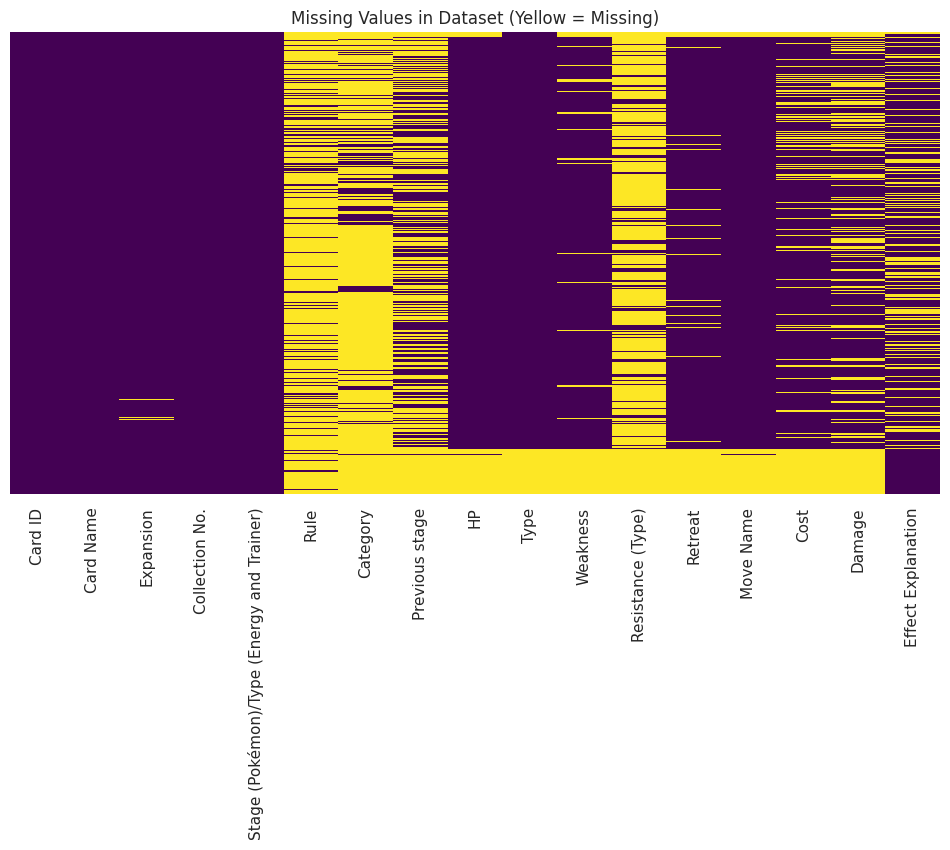

Missing Values per Column:
Expansion               10
Rule                  1669
Category              1630
Previous stage        1165
HP                     207
Type                   197
Weakness               288
Resistance (Type)     1646
Retreat                274
Move Name              211
Cost                   466
Damage                 737
Effect Explanation     541
dtype: int64


In [4]:
# Visualizing missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values in Dataset (Yellow = Missing)')
plt.show()

missing_counts = df.isnull().sum()
print("Missing Values per Column:")
print(missing_counts[missing_counts > 0])

## 3. Card Categories Distribution
Let's see the balance between Pokémon, Trainer, and Energy cards.

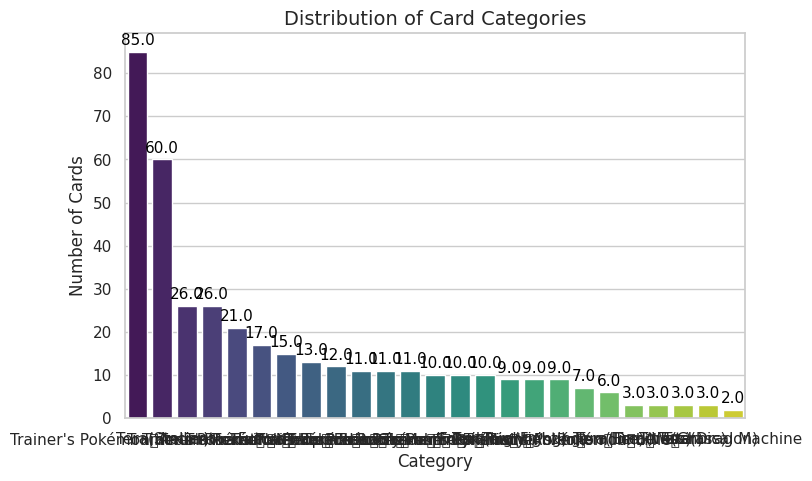

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='viridis')
plt.title('Distribution of Card Categories', fontsize=14)
plt.ylabel('Number of Cards')
plt.xlabel('Category')

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

## 4. Pokémon Cards Deep Dive

In [6]:
# Filter to only Pokémon cards
pokemon_df = df[df['Category'].str.contains('Pokémon', case=False, na=False)].copy()
print(f"Total Pokémon Cards: {len(pokemon_df)}")

if len(pokemon_df) == 0:
    # Fallback if text matching fails due to encoding
    pokemon_df = df[df['HP'].notna()].copy()
    print(f"Fallback - Total Pokémon Cards (cards with HP): {len(pokemon_df)}")

Total Pokémon Cards: 241


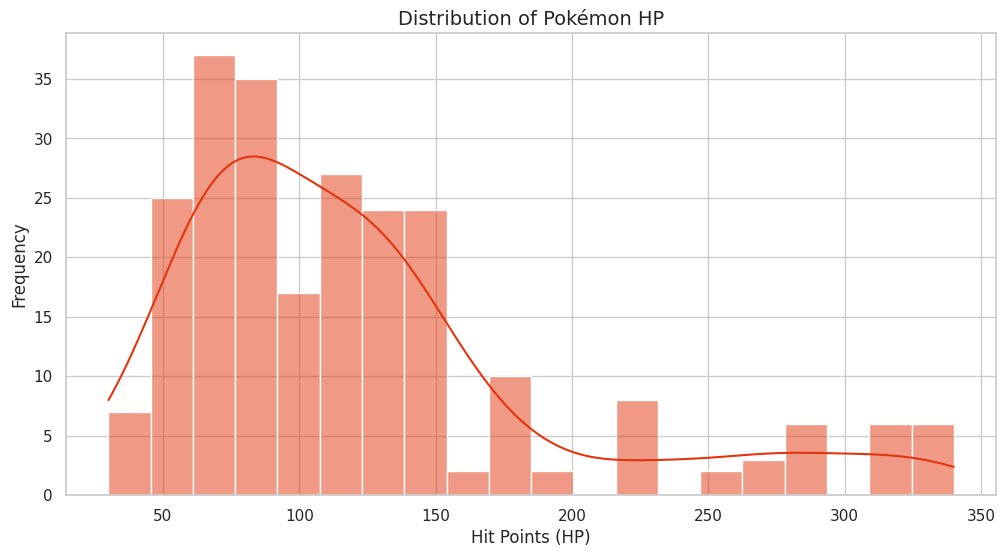

Average HP: 123.7
Max HP: 340


In [7]:
# 4.1 Pokémon HP Distribution
# Clean HP: Extract numeric part (e.g., in case there's '120 HP')
pokemon_df['HP_Num'] = pd.to_numeric(pokemon_df['HP'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

plt.figure(figsize=(12, 6))
sns.histplot(pokemon_df['HP_Num'].dropna(), bins=20, kde=True, color='#E3350D')
plt.title('Distribution of Pokémon HP', fontsize=14)
plt.xlabel('Hit Points (HP)')
plt.ylabel('Frequency')
plt.show()

print(f"Average HP: {pokemon_df['HP_Num'].mean():.1f}")
print(f"Max HP: {pokemon_df['HP_Num'].max()}")

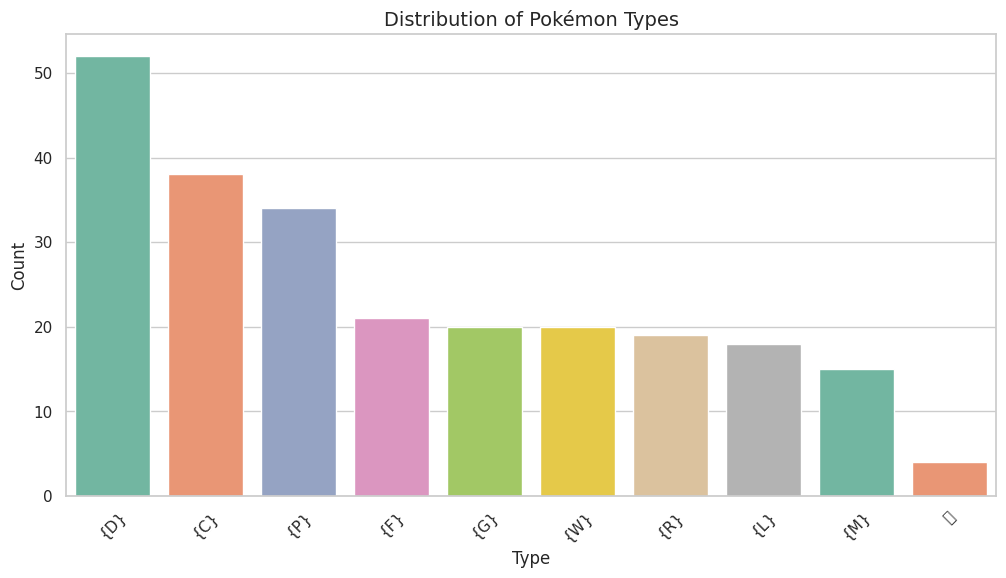

In [8]:
# 4.2 Pokémon Type Distribution
plt.figure(figsize=(12, 6))
type_counts = pokemon_df['Type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, palette='Set2')
plt.title('Distribution of Pokémon Types', fontsize=14)
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

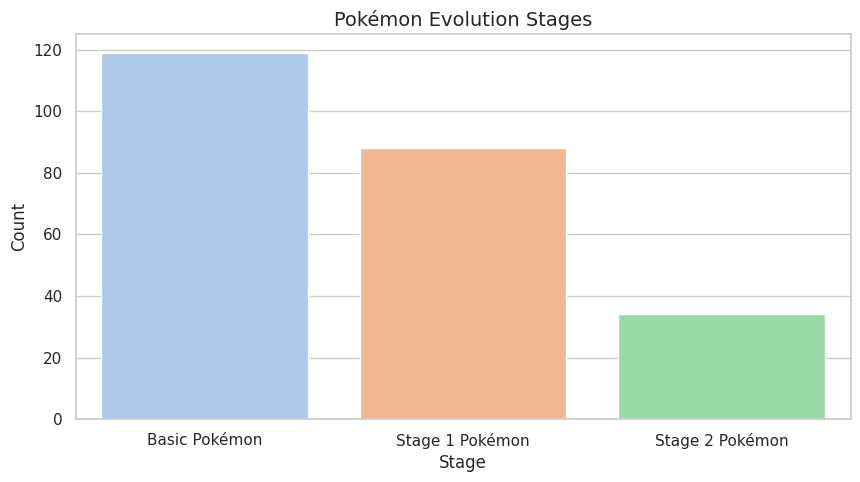

In [9]:
# 4.3 Evolution Stages
# The exact column name might vary slightly (e.g. Stage (Pokémon) / Type (Energy and Trainer))
stage_col = [col for col in pokemon_df.columns if 'Stage' in col][0]

plt.figure(figsize=(10, 5))
sns.countplot(data=pokemon_df, x=stage_col, order=pokemon_df[stage_col].value_counts().index, palette='pastel')
plt.title('Pokémon Evolution Stages', fontsize=14)
plt.xlabel('Stage')
plt.ylabel('Count')
plt.show()

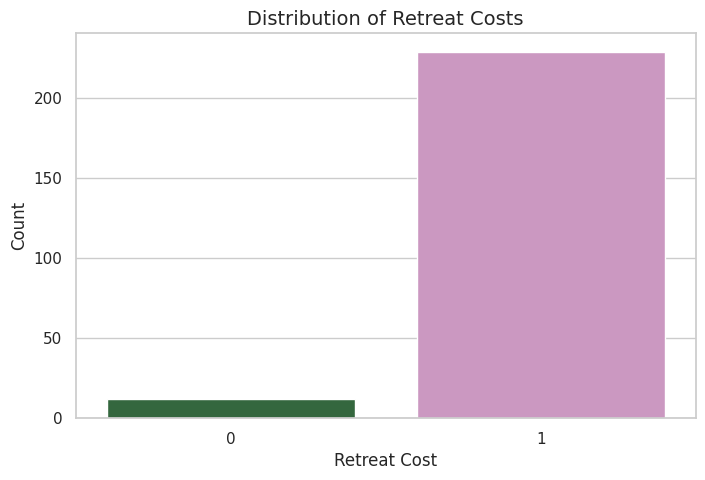

In [10]:
# 4.4 Retreat Cost Distribution
pokemon_df['Retreat_Cost'] = pokemon_df['Retreat'].astype(str).apply(lambda x: len(x.split()) if x != 'nan' else 0)

plt.figure(figsize=(8, 5))
sns.countplot(data=pokemon_df, x='Retreat_Cost', palette='cubehelix')
plt.title('Distribution of Retreat Costs', fontsize=14)
plt.xlabel('Retreat Cost')
plt.ylabel('Count')
plt.show()

## 5. Trainer & Energy Cards Analysis

In [11]:
# Trainer Cards
trainer_df = df[df['Category'] == 'Trainer'].copy()

if not trainer_df.empty:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=trainer_df, x=stage_col, order=trainer_df[stage_col].value_counts().index, palette='Set3')
    plt.title('Trainer Card Types (Item, Supporter, Stadium, etc.)', fontsize=14)
    plt.xlabel('Trainer Type')
    plt.ylabel('Count')
    plt.show()
else:
    print("No Trainer cards identified. Check 'Category' column values.")

No Trainer cards identified. Check 'Category' column values.


In [12]:
# Energy Cards
energy_df = df[df['Category'] == 'Energy'].copy()
if not energy_df.empty:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=energy_df, x=stage_col, order=energy_df[stage_col].value_counts().index, palette='autumn')
    plt.title('Energy Card Types', fontsize=14)
    plt.xlabel('Energy Type')
    plt.ylabel('Count')
    plt.show()

## 6. Attack Damage Analysis
Let's look at the damage numbers dealt by Pokémon attacks.

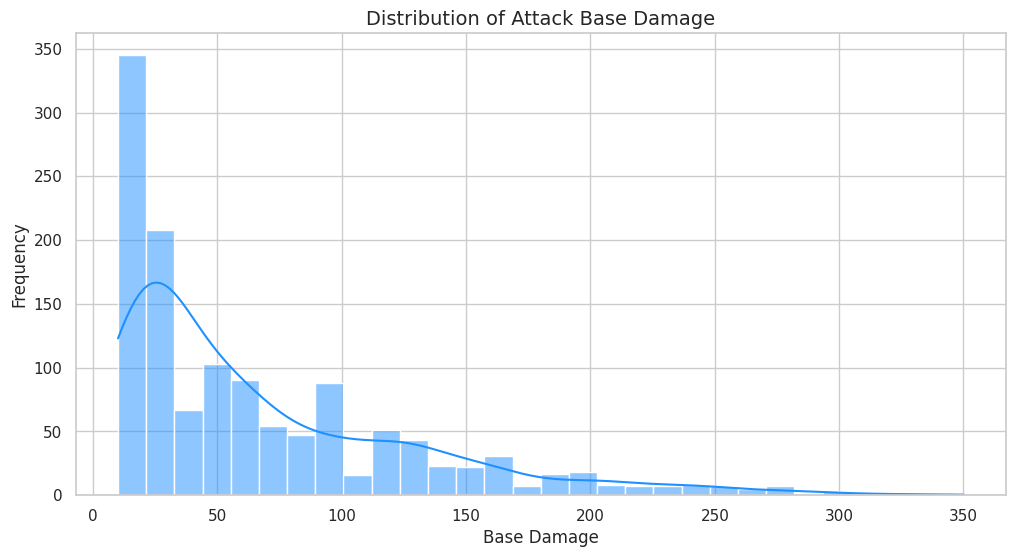

Average Base Damage: 68.0
Max Base Damage: 350.0


In [13]:
if 'Damage' in df.columns:
    # Extract numeric base damage, ignoring '+' or 'x' multipliers for this basic analysis
    df['Base_Damage'] = pd.to_numeric(df['Damage'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
    
    plt.figure(figsize=(12, 6))
    sns.histplot(df['Base_Damage'].dropna(), bins=30, kde=True, color='#1e90ff')
    plt.title('Distribution of Attack Base Damage', fontsize=14)
    plt.xlabel('Base Damage')
    plt.ylabel('Frequency')
    plt.show()
    
    print(f"Average Base Damage: {df['Base_Damage'].mean():.1f}")
    print(f"Max Base Damage: {df['Base_Damage'].max()}")

---
### Conclusion
This notebook provides a robust starting point for your EDA in the Pokémon TCG AI Battle Challenge. 
Feel free to branch off this notebook and dive deeper into specific expansions, analyze text effects, or model winning probabilities based on these card stats!

*Happy Kaggling!*